# MLA Lab — Bias–Variance in Unsupervised Learning (K-means & GMM)





This notebook addresses Parts 1–4 of the lab:
1) Synthetic 2D Gaussian mixture (ground truth known, K*=3)  
2) K-means for K=1..10: distortion, stability, ARI  
3) GMM-EM for K=1..10 and covariance types: train/val log-likelihood  
4) Empirical bias–variance estimation over B datasets

Every figure includes: axes + caption + takeaway.

Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

Small helpers

In [ ]:
def mean_std(x):
    x = np.asarray(x)
    return float(x.mean()), float(x.std())

def plot_scatter(X, labels=None, title="", xlabel="x1", ylabel="x2"):
    plt.figure(figsize=(5,4))
    if labels is None:
        plt.scatter(X[:,0], X[:,1], s=12, alpha=0.8)
    else:
        plt.scatter(X[:,0], X[:,1], c=labels, s=12, alpha=0.8)
    plt.title(title)
    plt.xlabel(xlabel); plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

## Part 1 — Synthetic data (K* = 3)

We define a true 2D Gaussian mixture with:
- non-uniform weights π
- reasonably separated means μk (not trivial)
- different covariances Σk (at least one anisotropic)

We generate:
- training set: n_train = 500
- validation set: n_val = 1000

Choose true parameters

In [ ]:
K_star = 3
pi_true = np.array([0.55, 0.25, 0.20])  # not equal

mu_true = np.array([
    [-2.2,  0.7],
    [ 1.3,  2.2],
    [ 2.6, -1.4]
])

Sigma_true = np.array([
    [[1.0,  0.35],
     [0.35, 0.55]],   # anisotropic (correlated)
    [[0.55, 0.0],
     [0.0,  1.10]],   # diagonal, different scale
    [[0.40, -0.18],
     [-0.18, 0.65]]   # full, different shape
])

assert np.isclose(pi_true.sum(), 1.0)

Sampling from the true mixture

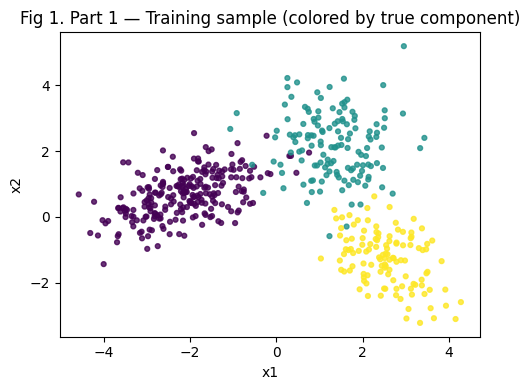

In [ ]:
def sample_true_gmm(n, pi, mus, Sigmas, seed=None):
    rng = np.random.default_rng(seed)
    K = len(pi)
    z = rng.choice(K, size=n, p=pi)
    X = np.zeros((n, 2))
    for k in range(K):
        idx = np.where(z == k)[0]
        if len(idx) > 0:
            X[idx] = rng.multivariate_normal(mus[k], Sigmas[k], size=len(idx))
    return X, z

n_train, n_val = 500, 1000
X_train, z_train = sample_true_gmm(n_train, pi_true, mu_true, Sigma_true, seed=0)
X_val,   z_val   = sample_true_gmm(n_val,   pi_true, mu_true, Sigma_true, seed=1)

plot_scatter(X_train, z_train, title="Fig 1. Part 1 — Training sample (colored by true component)")

### Exercise 1 — Answers

**(1) Parameters chosen**
- π = (0.55, 0.25, 0.20)
- μ1 = (-2.2, 0.7), μ2 = (1.3, 2.2), μ3 = (2.6, -1.4)
- Σ1 is anisotropic with correlation, Σ2 is diagonal, Σ3 is full.

**Figure (comment):**
- Axes: (x1, x2) are teh two features in the dataset
- Caption: One realization of the synthetic mixture (train set), colored by true component.
- Takeaway: clusters have different shapes (elliptical vs more circular), so K-means is not perfectly matched while GMM with full covariance can better fit.

**(2) Why synthetic data helps**
Because ground truth is known: we can evaluate clustering quality (e.g., ARI), study sensitivity to initialization and sampling, and analyze how increasing model complexity affects under/over-structuring in a controlled setting. Also it is useful for reproducing experiment when used with seed.

## Part 2 — K-means and bias–variance

Key choice (fast + solid): stability via partition agreement

Instead of matching centers (slow), use stability(K) = average ARI between runs (labels from different initializations). This is allowed by the statement (“variation of partitions”). It runs fast.

K-means metrics for a given K

In [ ]:
def kmeans_runs(X, K, R=20, seed0=0):
    inertias = []
    labels_list = []
    centers_list = []

    for r in range(R):
        km = KMeans(n_clusters=K, n_init=1, init="k-means++", random_state=seed0 + r)
        km.fit(X)
        inertias.append(km.inertia_)
        labels_list.append(km.labels_)
        centers_list.append(km.cluster_centers_)
    return np.array(inertias), labels_list, centers_list

def stability_partition_ari(labels_list):
    # average ARI across all pairs of runs
    R = len(labels_list)
    if R < 2:
        return np.nan
    vals = []
    for i in range(R):
        for j in range(i+1, R):
            vals.append(adjusted_rand_score(labels_list[i], labels_list[j]))
    return float(np.mean(vals))

Exercise 2: run K=1..10, compute mean±std distortion, stability, ARI vs GT

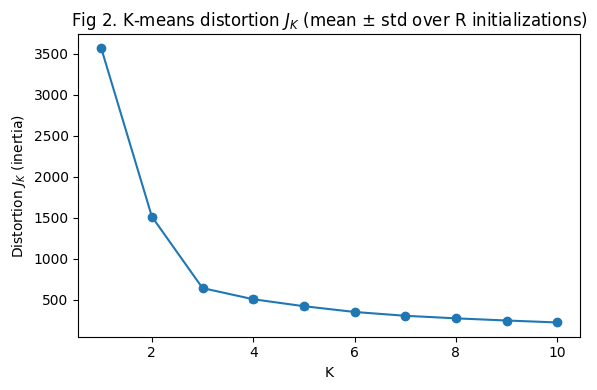

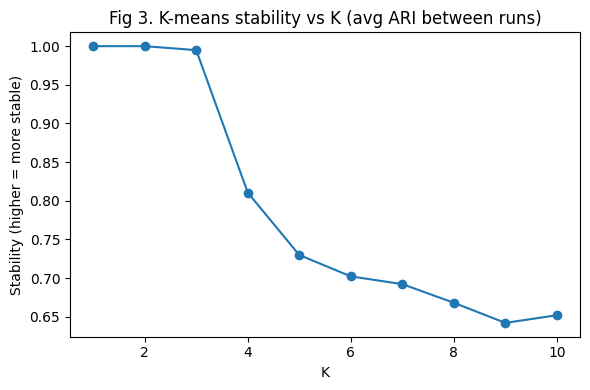

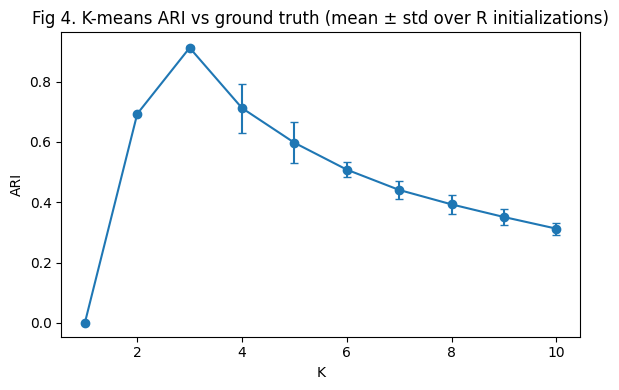

In [ ]:
Ks = list(range(1, 11))
R = 20

mean_J, std_J = [], []
stabK = []
mean_ARI, std_ARI = [], []

for K in Ks:
    inertias, labels_list, _ = kmeans_runs(X_train, K, R=R, seed0=10)
    mJ, sJ = mean_std(inertias)
    mean_J.append(mJ); std_J.append(sJ)

    # stability via partition ARI between runs
    stabK.append(stability_partition_ari(labels_list))

    # ARI vs true labels (ground truth known)
    aris = [adjusted_rand_score(z_train, lab) for lab in labels_list]
    mA, sA = mean_std(aris)
    mean_ARI.append(mA); std_ARI.append(sA)

# Distortion plot
plt.figure(figsize=(6,4))
plt.errorbar(Ks, mean_J, yerr=std_J, marker="o", capsize=3)
plt.title("Fig 2. K-means distortion $J_K$ (mean ± std over R initializations)")
plt.xlabel("K"); plt.ylabel("Distortion $J_K$ (inertia)")
plt.tight_layout()
plt.show()

# Stability plot
plt.figure(figsize=(6,4))
plt.plot(Ks, stabK, marker="o")
plt.title("Fig 3. K-means stability vs K (avg ARI between runs)")
plt.xlabel("K"); plt.ylabel("Stability (higher = more stable)")
plt.tight_layout()
plt.show()

# ARI vs ground truth plot
plt.figure(figsize=(6,4))
plt.errorbar(Ks, mean_ARI, yerr=std_ARI, marker="o", capsize=3)
plt.title("Fig 4. K-means ARI vs ground truth (mean ± std over R initializations)")
plt.xlabel("K"); plt.ylabel("ARI")
plt.tight_layout()
plt.show()

### Exercise 2 — Answers

**(1) Distortion mean±std vs K**
- Axes: K (x-axis) and inertia J_K (y-axis).
- Caption: Mean and std of K-means objective over R random initializations.
- Takeaway: J_K decreases with K (more clusters → better fit). Large std indicates sensitivity to initialization (multiple local minima), often appearing when K is not well supported by the data.

**(2) Stability measure**
We use *variation of partitions* via the average ARI between solutions obtained from different initializations:
Stability(K) = average_{i<j} ARI( partition_i, partition_j ).
- High stability means different initializations produce similar partitions.
- Low stability means the algorithm is sensitive to initialization (higher variance).

**(3) Bias–variance trade-off (K-means)**
- Small K: under-structuring → high bias (clusters merged), typically higher stability (low variance).
- Large K: can over-structure/split true components → lower bias but higher variance (more local minima, less stable partitions).

## Part 3 — GMM-EM: flexibility, overfitting

 GMM train/val log-likelihood over K and covariance type, with R initializations

In [ ]:
def gmm_ll_over_R(Xtr, Xva, K, cov_type, R=20, seed0=0):
    ll_tr, ll_va = [], []
    for r in range(R):
        gmm = GaussianMixture(
            n_components=K,
            covariance_type=cov_type,   # "spherical", "diag", "full"
            n_init=1,
            random_state=seed0 + r,
            reg_covar=1e-6
        )
        gmm.fit(Xtr)
        ll_tr.append(gmm.score(Xtr))  # avg log-likelihood per sample
        ll_va.append(gmm.score(Xva))
    return np.array(ll_tr), np.array(ll_va)

Ks = list(range(1, 11))
R = 20
cov_types = ["spherical", "diag", "full"]

results = {ct: {"tr_m":[], "tr_s":[], "va_m":[], "va_s":[]} for ct in cov_types}

for ct in cov_types:
    for K in Ks:
        ll_tr, ll_va = gmm_ll_over_R(X_train, X_val, K, ct, R=R, seed0=100)
        m1, s1 = mean_std(ll_tr)
        m2, s2 = mean_std(ll_va)
        results[ct]["tr_m"].append(m1); results[ct]["tr_s"].append(s1)
        results[ct]["va_m"].append(m2); results[ct]["va_s"].append(s2)

Plot for each covariance type (train and validation)

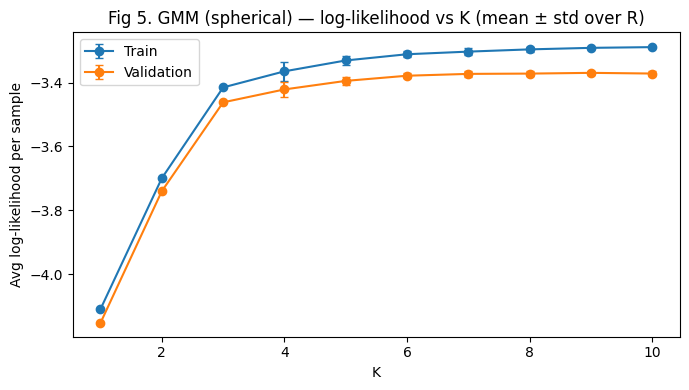

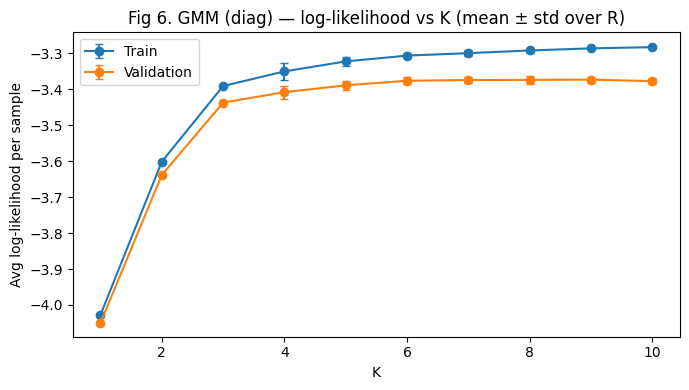

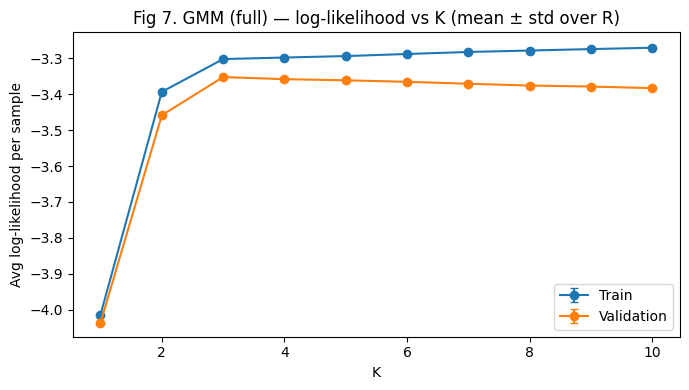

In [ ]:
for i, ct in enumerate(cov_types):
    plt.figure(figsize=(7,4))
    plt.errorbar(Ks, results[ct]["tr_m"], yerr=results[ct]["tr_s"], marker="o", capsize=3, label="Train")
    plt.errorbar(Ks, results[ct]["va_m"], yerr=results[ct]["va_s"], marker="o", capsize=3, label="Validation")
    plt.title(f"Fig {5 + i}. GMM ({ct}) — log-likelihood vs K (mean ± std over R)")
    plt.xlabel("K"); plt.ylabel("Avg log-likelihood per sample")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Exercise 3 — Answers

**(1) Log-likelihood curves**
- Axes: K vs average log-likelihood (train and validation).
- Caption: Mean ± std across R initializations.
- Takeaway: Train log-likelihood generally increases with K (more flexible model). Validation may saturate or decrease at large K (overfitting), especially for the most flexible covariance type.

**(2) K-means vs GMM (qualitative)**
- K-means: hard assignments, Voronoi partitions, implicitly favors spherical clusters with similar sizes.
- GMM: soft assignments and explicit covariance modeling, can represent elliptical clusters and unequal spreads, often better aligned with heterogeneous Σ_k.

**(3) Effect of covariance constraint**
- spherical: simplest → higher bias, lower variance (stable but less expressive).
- diag: intermediate flexibility → moderate bias/variance.
- full: most flexible → lowest bias but higher variance and more prone to overfitting with large K.

## Part 4 — Empirical bias–variance estimation (over B datasets)

We follow the lab: repeat over B independent datasets, train models, evaluate on a large validation set from the true distribution, compare two complexity levels.

Part 4 protocol implementation

In [ ]:
B = 50
n_train = 500
n_val_big = 5000

# fixed large validation set from the true distribution
X_val_big, z_val_big = sample_true_gmm(n_val_big, pi_true, mu_true, Sigma_true, seed=999)

def fit_best_gmm_by_train_ll(Xtr, K, cov_type, R=10, seed0=0):
    best_model, best_ll = None, -np.inf
    for r in range(R):
        gmm = GaussianMixture(
            n_components=K,
            covariance_type=cov_type,
            n_init=1,
            random_state=seed0 + r,
            reg_covar=1e-6
        )
        gmm.fit(Xtr)
        ll = gmm.score(Xtr)
        if ll > best_ll:
            best_ll = ll
            best_model = gmm
    return best_model

# Two complexity levels (example requested in the lab statement)
configs = [
    ("LowComplexity",  2, "diag"),
    ("HighComplexity", 8, "full"),
]

nll_across_B = {name: [] for (name,_,_) in configs}

for b in range(B):
    Xb, zb = sample_true_gmm(n_train, pi_true, mu_true, Sigma_true, seed=2000+b)
    for (name, K, ct) in configs:
        model = fit_best_gmm_by_train_ll(Xb, K=K, cov_type=ct, R=10, seed0=3000 + b*100)
        nll = - model.score(X_val_big)  # negative avg log-likelihood on big validation set
        nll_across_B[name].append(nll)

for name in nll_across_B:
    arr = np.array(nll_across_B[name])
    print(name, "mean NLL:", arr.mean(), "std NLL:", arr.std())

LowComplexity mean NLL: 3.5950910854303104 std NLL: 0.004060160699754178
HighComplexity mean NLL: 3.358384162386626 std NLL: 0.011163502732149487


Plot variance across datasets + mean±std summary

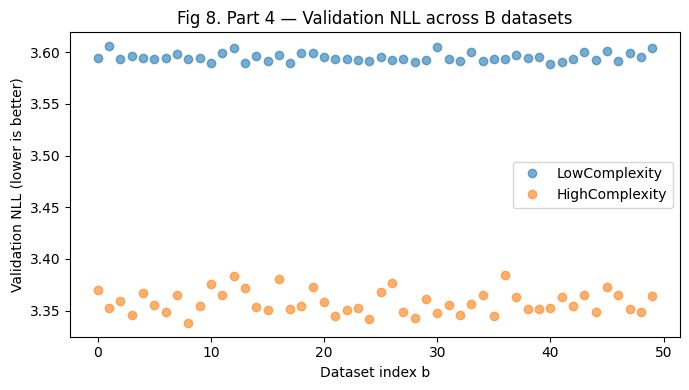

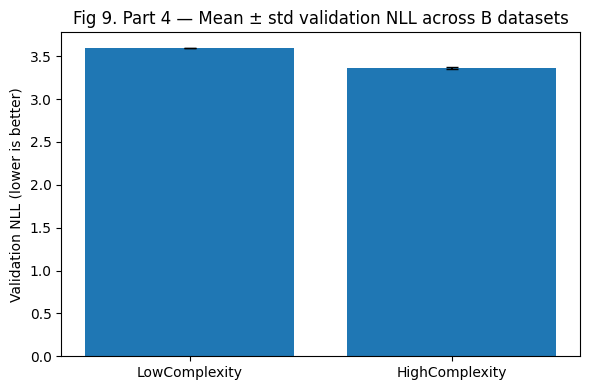

In [ ]:
# Scatter of NLL values across datasets
plt.figure(figsize=(7,4))
for name, vals in nll_across_B.items():
    plt.plot(vals, marker="o", linestyle="", alpha=0.6, label=name)
plt.title("Fig 8. Part 4 — Validation NLL across B datasets")
plt.xlabel("Dataset index b"); plt.ylabel("Validation NLL (lower is better)")
plt.legend()
plt.tight_layout()
plt.show()

# Bar plot mean±std
names = list(nll_across_B.keys())
means = [np.mean(nll_across_B[n]) for n in names]
stds  = [np.std(nll_across_B[n]) for n in names]

plt.figure(figsize=(6,4))
plt.bar(names, means, yerr=stds, capsize=4)
plt.title("Fig 9. Part 4 — Mean ± std validation NLL across B datasets")
plt.ylabel("Validation NLL (lower is better)")
plt.tight_layout()
plt.show()

### Exercise 4 — Answers

**(1) Protocol**
For b=1..B:
1) Sample a training set X_train^(b) from the true distribution.
2) Fit a model (select best over R initializations).
3) Evaluate on a fixed large validation set X_val_big from the true distribution.

We use validation NLL (negative avg log-likelihood) as an error proxy.

**(2) Compare two complexity levels**
Example: GMM (K=2, diag) vs GMM (K=8, full).
- Bias proxy: higher mean validation NLL indicates underfitting (bias).
- Variance proxy: higher std of validation NLL across datasets indicates sensitivity to sampling (variance).

**(3) Limitations of bias–variance in unsupervised learning**
There is no single supervised target. Conclusions depend on the chosen metric (NLL, distortion, ARI).
Identifiability / label switching makes parameter-based comparisons difficult.
Different models optimize different objectives (K-means vs GMM).